# Data Generation Demo

This notebook reads one case from `CT_RATE_demo_data`, exports NPZ files, inspects their structure, and creates a few training samples from the generated NPZ.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'paligemma_training_data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'training_file_generation'))
sys.path.insert(0, str(PROJECT_ROOT / 'paligemma_training_data'))
sys.path.insert(0, str(PROJECT_ROOT))

from generate_training_files import get_image_info
from paligemma_training_sample_generator import PaligemmaSampleGenerator

DEMO_ROOT = PROJECT_ROOT / 'CT_RATE_demo_data'
OUTPUT_DIR = PROJECT_ROOT / 'demo' / 'generated_npz_demo'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PA_CASE_DIR = DEMO_ROOT / 'CT_RATE_projections_PA' / 'train_1_a_2'
LR_CASE_DIR = DEMO_ROOT / 'CT_RATE_projections_LR' / 'train_1_a_2'
PA_NPZ_PATH = OUTPUT_DIR / 'train_1_a_2_PA.npz'
LR_NPZ_PATH = OUTPUT_DIR / 'train_1_a_2_LR.npz'

print(f'Project root: {PROJECT_ROOT}')
print(f'PA case dir: {PA_CASE_DIR}')
print(f'LR case dir: {LR_CASE_DIR}')
print(f'NPZ output dir: {OUTPUT_DIR}')

Project root: /home/sgatidis/Projects/cheXanatomy
PA case dir: /home/sgatidis/Projects/cheXanatomy/CT_RATE_demo_data/CT_RATE_projections_PA/train_1_a_2
LR case dir: /home/sgatidis/Projects/cheXanatomy/CT_RATE_demo_data/CT_RATE_projections_LR/train_1_a_2
NPZ output dir: /home/sgatidis/Projects/cheXanatomy/demo/generated_npz_demo


In [2]:
def list_case_pngs(case_dir):
    return sorted(path.name for path in case_dir.glob('*.png'))

pa_pngs = list_case_pngs(PA_CASE_DIR)
lr_pngs = list_case_pngs(LR_CASE_DIR)

print('PA case files:', pa_pngs[:10], '... total =', len(pa_pngs))
print('LR case files:', lr_pngs[:10], '... total =', len(lr_pngs))

PA case files: ['aorta.png', 'body.png', 'bones.png', 'brachiocephalic_vein_left.png', 'brachiocephalic_vein_right.png', 'bronchia.png', 'clavicula_left.png', 'clavicula_right.png', 'colon.png', 'costal_cartilages.png'] ... total = 90
LR case files: ['aorta.png', 'body.png', 'bones.png', 'brachiocephalic_vein_left.png', 'brachiocephalic_vein_right.png', 'bronchia.png', 'clavicula_left.png', 'clavicula_right.png', 'colon.png', 'costal_cartilages.png'] ... total = 90


In [3]:
pa_info = get_image_info(str(PA_CASE_DIR), export_npz=True, npz_path=str(PA_NPZ_PATH))
lr_info = get_image_info(str(LR_CASE_DIR), export_npz=True, npz_path=str(LR_NPZ_PATH))

summary = {
    'PA': {'case': pa_info['case'], 'orientation': pa_info['orientation'], 'num_structures': pa_info['num_structures']},
    'LR': {'case': lr_info['case'], 'orientation': lr_info['orientation'], 'num_structures': lr_info['num_structures']},
}
print(json.dumps(summary, indent=2))

2026-05-30 09:27:31.442251: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780158454.777807 2172518 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 78672 MB memory:  -> device: 0, name: NVIDIA H100 PCIe, pci bus id: 0000:08:00.0, compute capability: 9.0
2026-05-30 09:27:36.170701: E external/local_xla/xla/tsl/platform/default/port.cc:269] Failed to find hwloc NUMA node 3


Image info saved to /home/sgatidis/Projects/cheXanatomy/demo/generated_npz_demo/train_1_a_2_PA.npz
Image info saved to /home/sgatidis/Projects/cheXanatomy/demo/generated_npz_demo/train_1_a_2_LR.npz
{
  "PA": {
    "case": "train_1_a_2",
    "orientation": "PA",
    "num_structures": 80
  },
  "LR": {
    "case": "train_1_a_2",
    "orientation": "LR",
    "num_structures": 80
  }
}


In [4]:
loaded = np.load(PA_NPZ_PATH, allow_pickle=True)
metadata = loaded['metadata'].item()

print('NPZ arrays:', loaded.files)
print('Image shape:', loaded['img_array'].shape)
print('Metadata keys:', sorted(metadata.keys()))

structure_names = sorted(metadata['structure_info'].keys())
print('First 10 structures:', structure_names[:10])
sample_structure = structure_names[0]
print('Example structure metadata:')
print(json.dumps(metadata['structure_info'][sample_structure], indent=2))

NPZ arrays: ['img_array', 'metadata']
Image shape: (896, 896)
Metadata keys: ['case', 'img_shape', 'num_structures', 'orientation', 'structure_info']
First 10 structures: ['aorta', 'body', 'bones', 'brachiocephalic_vein_left', 'brachiocephalic_vein_right', 'bronchia', 'clavicula_left', 'clavicula_right', 'colon', 'costal_cartilages']
Example structure metadata:
{
  "label": "aorta",
  "bbox": [
    280,
    357,
    721,
    574
  ],
  "bbox_norm": [
    0.312,
    0.398,
    0.805,
    0.641
  ],
  "bbox_token": "<loc0319><loc0407><loc0824><loc0656>",
  "segmentation_token": "<loc0319><loc0407><loc0824><loc0656><seg066><seg067><seg116><seg092><seg027><seg013><seg112><seg018><seg089><seg114><seg088><seg031><seg011><seg057><seg003><seg027>"
}


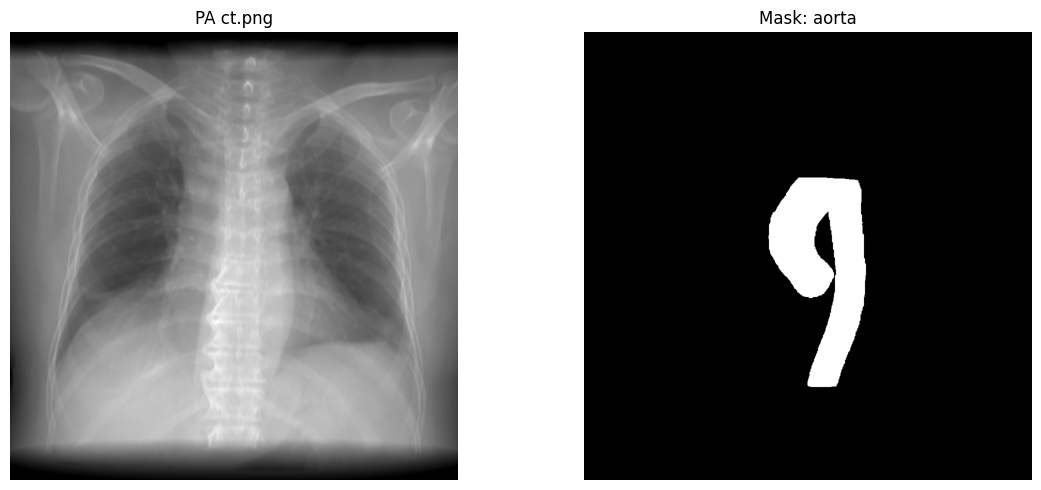

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(pa_info['img_array'], cmap='gray')
axes[0].set_title('PA ct.png')
axes[0].axis('off')

sample_mask_path = PA_CASE_DIR / f'{sample_structure}.png'
axes[1].imshow(np.array(Image.open(sample_mask_path).convert('L')), cmap='gray')
axes[1].set_title(f'Mask: {sample_structure}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [6]:
generator = PaligemmaSampleGenerator(str(PA_NPZ_PATH), enable_augmentation=False)
available_structures = generator.get_available_structures()
target_structure = 'heart' if 'heart' in available_structures else available_structures[0]

detection_sample = generator.generate_sample('detection', target_structure)
segmentation_sample = generator.generate_sample('segmentation', target_structure)
orientation_sample = generator.generate_sample('orientation_identification')

print('Detection prefix:', detection_sample.prefix)
print('Detection suffix:', detection_sample.suffix[:160])
print('Segmentation prefix:', segmentation_sample.prefix)
print('Segmentation suffix:', segmentation_sample.suffix[:160])
print('Orientation prompt:', orientation_sample.prefix)
print('Orientation answer:', orientation_sample.suffix)

Detection prefix: detect Heart
Detection suffix: <loc0392><loc0352><loc0765><loc0788> Heart
Segmentation prefix: segment Cor
Segmentation suffix: <loc0392><loc0352><loc0765><loc0788><seg105><seg051><seg004><seg028><seg075><seg122><seg004><seg063><seg030><seg069><seg035><seg042><seg014><seg078><seg099><seg
Orientation prompt: How is this slice oriented?
Orientation answer: posteroanterior


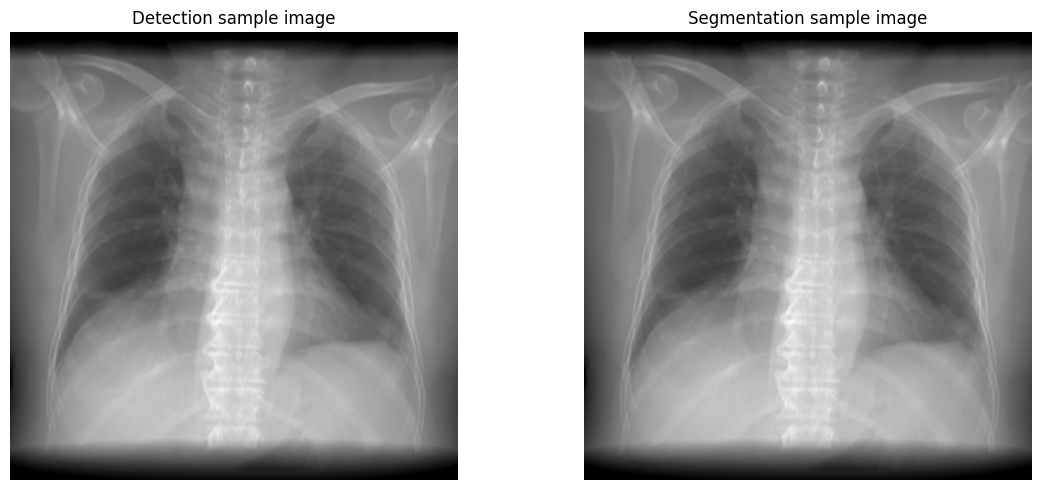

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(np.array(detection_sample.image), cmap='gray')
axes[0].set_title('Detection sample image')
axes[0].axis('off')

axes[1].imshow(np.array(segmentation_sample.image), cmap='gray')
axes[1].set_title('Segmentation sample image')
axes[1].axis('off')
plt.tight_layout()
plt.show()